In [21]:
from pathlib import Path
import sys
import time
import json
import joblib

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

In [22]:
DATA = PROJECT_ROOT / "data" / "processed"

X_train = pd.read_csv(DATA / "X_train_scaled.csv")

X_test = pd.read_csv(DATA / "X_test_scaled.csv")

y_train = pd.read_csv(DATA / "y_train.csv")["Label"]

y_test = pd.read_csv(DATA / "y_test.csv")["Label"]

label_encoder = joblib.load(DATA / "label_encoder.pkl")

print(X_train.shape)

print(X_test.shape)

(50400, 20)
(12600, 20)


In [23]:
rf = RandomForestClassifier(

    n_estimators=300,

    random_state=42,

    n_jobs=-1
)

start = time.time()

rf.fit(
    X_train,
    y_train
)

training_time = time.time() - start

print()

print("Training Time :", training_time)


Training Time : 79.54464101791382


In [24]:
start = time.time()

y_pred = rf.predict(X_test)

prediction_time = time.time() - start

print()

print("Prediction Time :", prediction_time)


Prediction Time : 0.6119875907897949


In [25]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("="*60)

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 :", f1)

print("="*60)

Accuracy : 0.986031746031746
Precision : 0.9861260648844351
Recall : 0.986031746031746
F1 : 0.9860322332153569


In [26]:
report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
)

print(report)

              precision    recall  f1-score   support

      AM-SSB       0.97      1.00      0.98      1800
        BPSK       0.98      0.99      0.98      1800
       CPFSK       0.99      0.99      0.99      1800
        GFSK       0.99      0.99      0.99      1800
        PAM4       0.99      0.97      0.98      1800
       QAM64       0.99      0.98      0.99      1800
        QPSK       0.99      0.98      0.98      1800

    accuracy                           0.99     12600
   macro avg       0.99      0.99      0.99     12600
weighted avg       0.99      0.99      0.99     12600



In [27]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm_df = pd.DataFrame(
    cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

cm_df

,AM-SSB,BPSK,CPFSK,GFSK,PAM4,QAM64,QPSK
AM-SSB,1799,0,0,0,0,1,0
BPSK,9,1774,0,0,17,0,0
CPFSK,0,0,1783,9,0,0,8
GFSK,0,0,15,1784,0,0,1
PAM4,14,30,0,0,1755,0,1
QAM64,18,0,0,0,2,1764,16
QPSK,16,0,4,1,1,13,1765


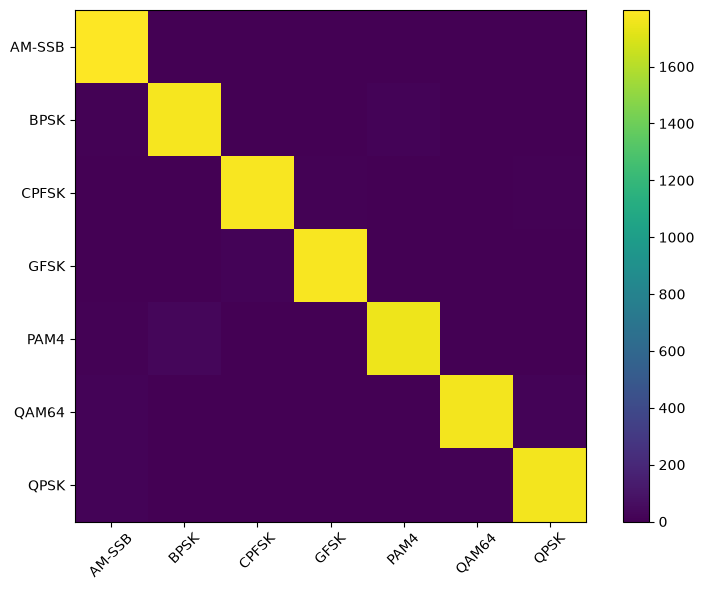

In [28]:
plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=45
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.colorbar()

plt.tight_layout()

plt.show()

In [29]:
per_class = cm.diagonal() / cm.sum(axis=1)

per_class_df = pd.DataFrame({

    "Modulation":label_encoder.classes_,

    "Accuracy":per_class

})

per_class_df

,Modulation,Accuracy
0,AM-SSB,0.999444
1,BPSK,0.985556
2,CPFSK,0.990556
3,GFSK,0.991111
4,PAM4,0.975000
5,QAM64,0.980000
6,QPSK,0.980556


In [30]:
importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
13,M20,0.116302
1,AmplitudeStd,0.101774
4,FrequencyStd,0.099062
7,SigmaZ2,0.082569
8,BlindSNR,0.067938
9,M2M4SNR,0.055648
19,R5,0.053042
10,SpectralEntropy,0.050729
17,R3,0.047071
14,C42,0.046896


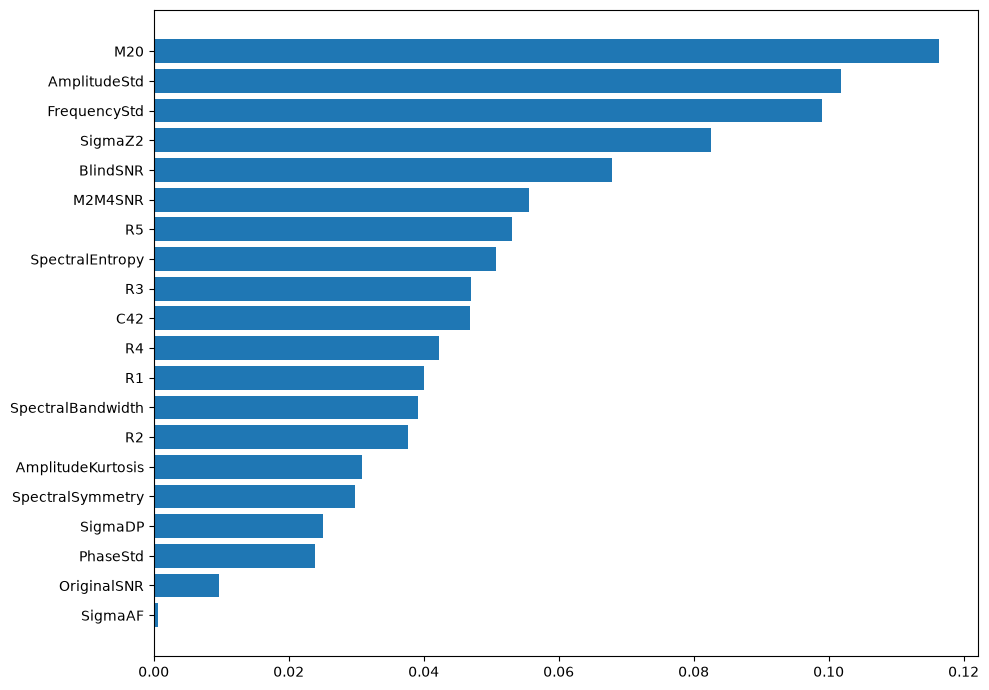

In [31]:
plt.figure(figsize=(10,7))

plt.barh(

    importance["Feature"],

    importance["Importance"]

)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [32]:
original = pd.read_csv(DATA / "feature_dataset_clean.csv")

test_index = y_test.index

snr = original.loc[test_index, "OriginalSNR"]

results = pd.DataFrame({

    "Actual":y_test,

    "Predicted":y_pred,

    "SNR":snr

})

snr_accuracy = results.groupby("SNR").apply(

    lambda x:(x.Actual==x.Predicted).mean()

)

snr_accuracy

SNR
2     0.987500
4     0.980000
6     0.987000
8     0.987667
10    0.983000
12    0.984000
14    0.989000
16    0.986667
dtype: float64

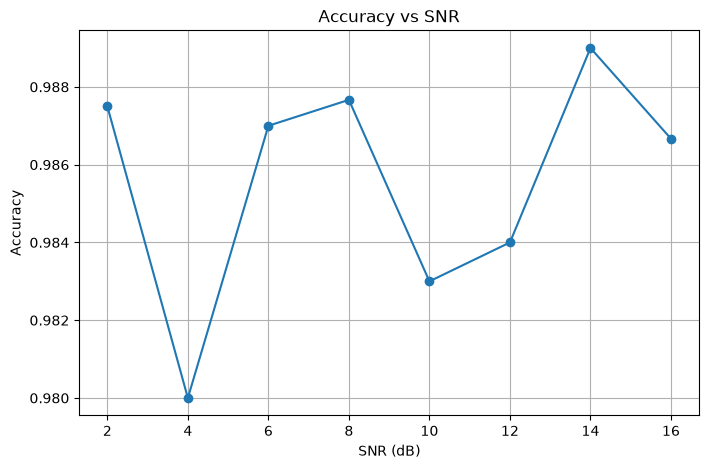

In [33]:
plt.figure(figsize=(8,5))

plt.plot(

    snr_accuracy.index,

    snr_accuracy.values,

    marker="o"

)

plt.grid(True)

plt.xlabel("SNR (dB)")

plt.ylabel("Accuracy")

plt.title("Accuracy vs SNR")

plt.show()

In [34]:
UNKNOWN_THRESHOLD = 0.75

def predict_signal(sample):

    prob = rf.predict_proba(sample)

    confidence = np.max(prob)

    prediction = np.argmax(prob)

    if confidence < UNKNOWN_THRESHOLD:

        return "Unknown", confidence

    return label_encoder.inverse_transform([prediction])[0], confidence

In [35]:
prediction, confidence = predict_signal(

    X_test.iloc[[0]]

)

print(prediction)

print(confidence)

AM-SSB
0.9233333333333333


In [36]:
MODEL = PROJECT_ROOT / "models"

MODEL.mkdir(

    parents=True,

    exist_ok=True

)

joblib.dump(

    rf,

    MODEL / "random_forest.pkl"

)

metadata = {

    "accuracy":float(accuracy),

    "precision":float(precision),

    "recall":float(recall),

    "f1":float(f1),

    "training_time":training_time,

    "prediction_time":prediction_time,

    "threshold":UNKNOWN_THRESHOLD

}

with open(

    MODEL / "random_forest_metadata.json",

    "w"

) as f:

    json.dump(

        metadata,

        f,

        indent=4

    )

print("Model Saved Successfully")

Model Saved Successfully


In [37]:
REPORT = PROJECT_ROOT / "results" / "reports"

REPORT.mkdir(

    parents=True,

    exist_ok=True

)

importance.to_csv(

    REPORT / "feature_importance.csv",

    index=False

)

per_class_df.to_csv(

    REPORT / "per_class_accuracy.csv",

    index=False

)

cm_df.to_csv(

    REPORT / "confusion_matrix.csv"

)

print("Reports Saved")

Reports Saved
